# Vizualizace dat s využitím knihovny Pandas

- Pandas nabízí jednoduchou integraci s knihovnou Matplotlib pro základní vizualizace dat pomocí metody `plot()`, která využívá sub-modul **Pyplot** knihovny Matplotlib (Matplotlib je samostatná knihovna pro vizualizace v Pythonu).
- Matplotlib je **knihovna pro vizualizaci na nízké úrovni**, což znamená, že umožňuje bohaté možnosti přizpůsobení grafů, ale může vyžadovat více nastavení.
- Metoda `plot()` v Pandas slouží k vytvoření různých typů vizualizací (např. čárové grafy, sloupcové grafy, bodové grafy).
    - **Argumenty**: `plot()` přijímá dva základní argumenty — první pro hodnoty na ose x, druhý pro hodnoty na ose y. Pokud není specifikována hodnota osy x, Pandas vygeneruje výchozí řadu indexů.
    - Typy grafů, které Matplotlib nabízí, naleznete [zde](https://matplotlib.org/stable/plot_types/index.html).

- Vizuály jsou vytvářeny v objektu **figure** (zkráceně **fig**), do kterého jsou následně přidávány jednotlivé grafy v podobě objektů **axes** (osy).

#### Dva režimy práce s Matplotlib

- **Stavový režim (Stateful)**: V tomto režimu je objekt figury vytvořen implicitně a veškeré operace se provádějí na tomto implicitním objektu. Není třeba explicitně vytvářet objekty figury nebo os. Tento režim je jednodušší a často se používá v rychlých vizualizacích nebo interaktivních prostředích (např. Jupyter Notebook).

- **Bezstavový režim (Stateless)**: Tento režim vyžaduje explicitní vytvoření objektu **figure** a práce s ním pomocí volání metod. Tento přístup je vhodnější pro pokročilé formátování a přizpůsobení grafů. Umožňuje větší kontrolu nad rozložením grafů, osami a dalšími prvky grafu.

#### Fig (Figura)
- Objekt **figure** představuje okno nebo kontejner, do kterého jsou přidávány grafy.
- Vytvoření objektu figury se provádí pomocí metody `figure()` z modulu `pyplot`.
- Parametry figury mohou zahrnovat velikost (`figsize`), rozlišení (`dpi`), rozložení atd.

#### Axes (Osy)
- Objekt **axes** představuje skutečný graf uvnitř figury, kde se vykreslují data.
- Objekt osy lze vytvořit pomocí metody `subplot()` nebo `add_subplot()` z modulu `pyplot`. Každý objekt axes má své vlastní osy x a y.
- Pokročilé formátování os (např. změna měřítka, popisky, rozsah os) lze provádět přes tento objekt.
- Metoda `subplot2grid()` umožňuje vytvořit mřížku více grafů v rámci jedné figury, což usnadňuje zobrazení více grafů najednou ve zvoleném rozložení.

### Typy grafů, které lze vytvořit pomocí Pandas a Matplotlib:
- **Čárový graf** (výchozí typ)
- **Sloupcový graf**
- **Bodový graf (scatter plot)**: Užívá se k vizualizaci vztahu mezi dvěma proměnnými.
- **Histogram**: Vhodný pro zobrazení distribuce dat.




In [ ]:
import pandas as pd
from IPython.core.pylabtools import figsize

weather = pd.read_csv('./data/pydata_data.csv', sep=";")

weather['YEAR'] = weather['DATE'].str[:4].astype(int)
weather['MONTH'] = weather['DATE'].str[5:7].astype(int)
weather['DAY'] = weather['DATE'].str[8:].astype(int)

weather['DATE'] = pd.to_datetime(weather['DATE'])

weather.info()
weather.head()

## Sloupcový graf

Vykreslíme graf vývoje srážek (PRCP) po letech.

In [3]:
weather_yearly = weather.groupby('YEAR')['PRCP'].sum()
weather_yearly

YEAR
2000    4799.9
2001    5192.9
2002    6707.3
2003    4297.5
2004    5596.1
2005    5641.4
2006    5415.2
2007    7079.9
2008    6576.8
2009    7743.2
2010    7965.4
2011    5562.1
2012    6425.4
2013    6825.9
2014    7393.1
2015    5484.3
2016    8167.3
2017    9849.4
2018    4919.2
2019    6675.9
2020    6679.2
Name: PRCP, dtype: float64

<Axes: xlabel='YEAR'>

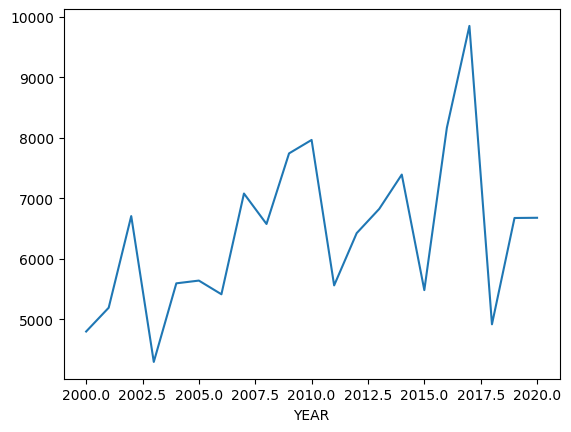

In [4]:
weather_yearly.plot()

<Axes: xlabel='YEAR'>

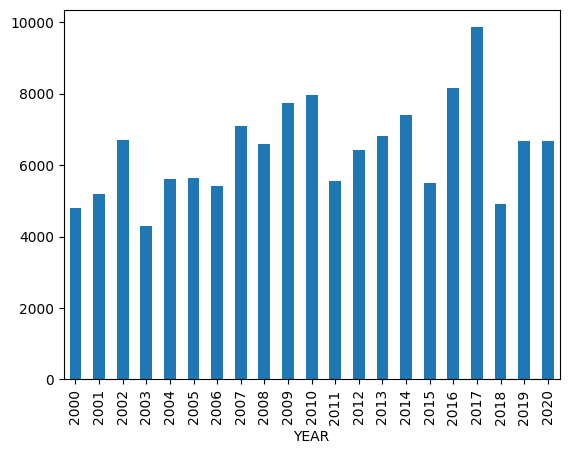

In [5]:
weather_yearly.plot(kind='bar')

<Axes: xlabel='YEAR'>

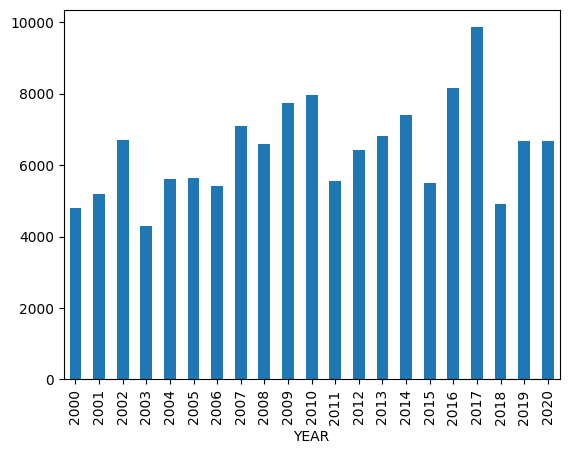

In [6]:
weather_yearly.plot(kind='bar', y='PRCP')

## Lineplot

     YEAR               NAME   PRCP
0    2000               GRAZ  755.3
1    2000             KOSICE  530.8
2    2000             MOSNOV  502.3
3    2000  PRAHA KLEMENTINUM  385.9
4    2000        PRAHA LIBUS  163.6
..    ...                ...    ...
184  2020        PRAHA LIBUS  611.1
185  2020             RUZYNE  547.1
186  2020           SALZBURG    8.6
187  2020             TURANY  610.6
188  2020               WIEN  499.3

[189 rows x 3 columns]


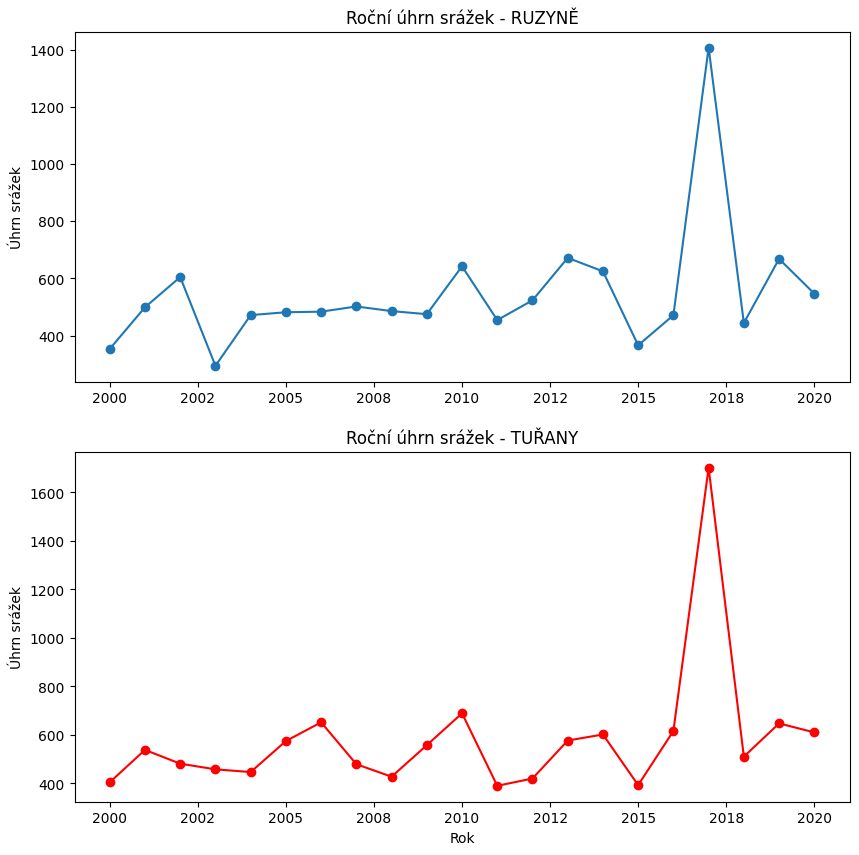

In [25]:
weather_agg = weather.groupby(['YEAR', 'NAME'])['PRCP'].sum().reset_index()
print(weather_agg)

from matplotlib import pyplot as plt
# vytvoříme dva grafy pro RUZYNE a TURANY
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=False)
#print(f"fig={fig}, ax={ax}")
ax[0].plot(weather_agg[weather_agg['NAME'] == 'RUZYNE']['YEAR'],  # osa x
           weather_agg[weather_agg['NAME'] == 'RUZYNE']['PRCP'],  # osa y
           marker='o',  # značka
           label='RUZYNĚ'
           )
ax[1].plot(weather_agg[weather_agg['NAME'] == 'TURANY']['YEAR'],  # osa x
           weather_agg[weather_agg['NAME'] == 'TURANY']['PRCP'],  # osa y
           marker='o',  # značka
           color='red',  # barva
           label='TURANY'
           )

# nastavíme title pro grafy
ax[0].set_title("Roční úhrn srážek - RUZYNĚ")
ax[1].set_title("Roční úhrn srážek - TUŘANY")

# label pro osy
ax[0].set_ylabel('Úhrn srážek')
ax[1].set_ylabel('Úhrn srážek')

ax[1].set_xlabel('Rok')

# nastavení hodnot na ose x - pouze celá čísla
ax[0].xaxis.set_major_formatter('{:.0f}'.format)
ax[1].xaxis.set_major_formatter('{:.0f}'.format)

## Histogram

<Axes: title={'center': 'Průměrná teplota'}, ylabel='Frequency'>

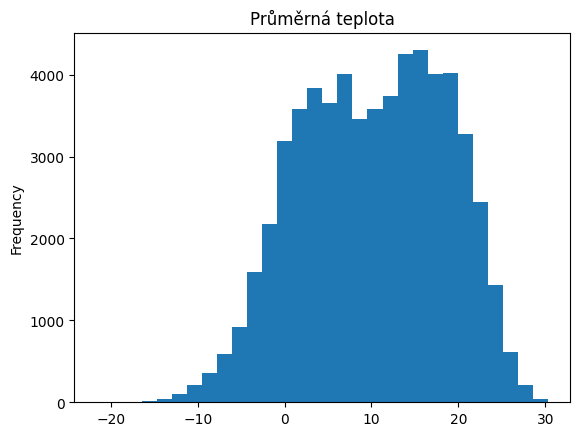

In [38]:
weather['TAVG'].plot(kind='hist', bins=30, title="Průměrná teplota")

## Boxplot

<Axes: >

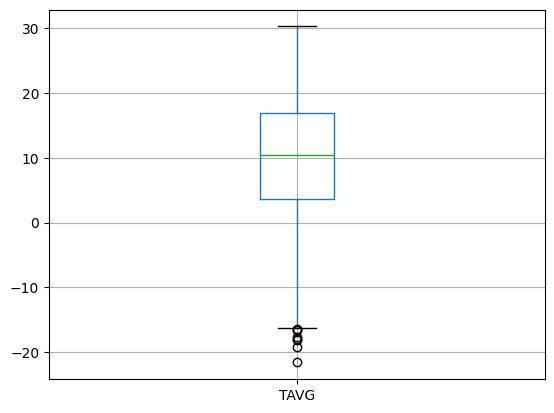

In [31]:
weather.boxplot(column='TAVG')

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'GRAZ'),
  Text(2, 0, 'KOSICE'),
  Text(3, 0, 'MOSNOV'),
  Text(4, 0, 'PIDING'),
  Text(5, 0, 'PRAHA KLEMENTINUM'),
  Text(6, 0, 'PRAHA LIBUS'),
  Text(7, 0, 'RUZYNE'),
  Text(8, 0, 'SALZBURG'),
  Text(9, 0, 'TURANY'),
  Text(10, 0, 'WIEN')])

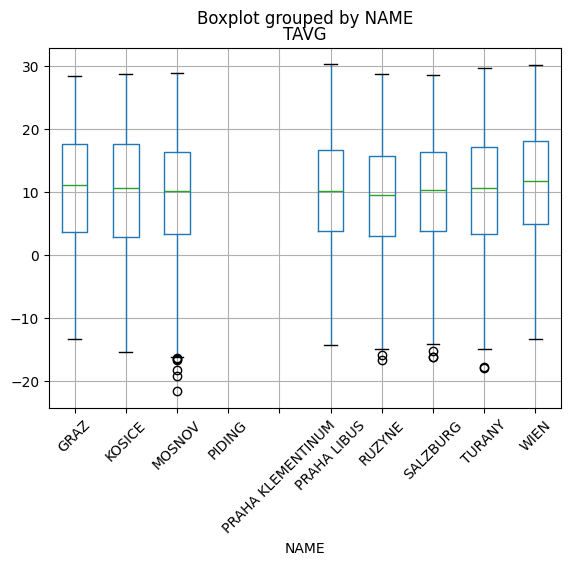

In [34]:
weather.boxplot(column='TAVG', by='NAME')
plt.xticks(rotation=45)

<Axes: title={'center': 'TAVG'}, xlabel='YEAR'>

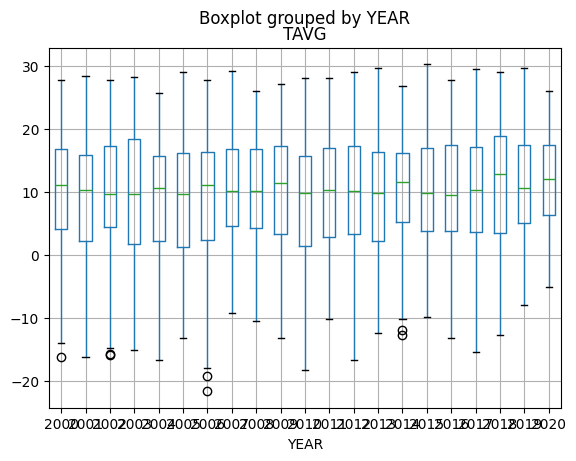

In [33]:
weather.boxplot(column='TAVG', by='YEAR')

## Q-Q graf

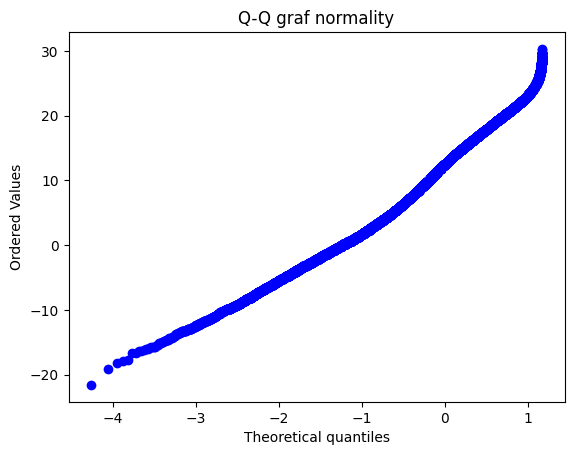

In [37]:
import scipy.stats as stats

stats.probplot(weather['TAVG'], dist='norm', plot=plt)
plt.title("Q-Q graf normality")
plt.show()

## KDE (Kernel Density Estimate)

<Axes: title={'center': 'Kernel Density Estimate'}, ylabel='Density'>

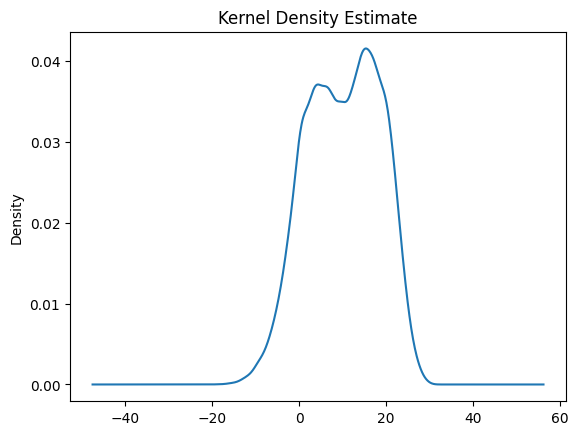

In [40]:
weather['TAVG'].plot(kind='density', title="Kernel Density Estimate")

### Spojení histogramu a KDE

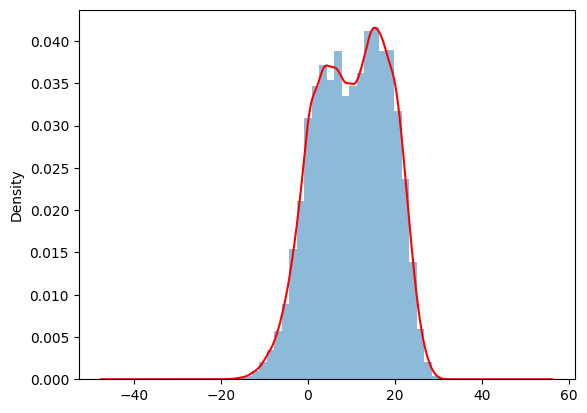

In [49]:
weather['TAVG'].plot(kind='hist', bins=30, density=True, alpha=0.5)
weather['TAVG'].plot(kind='kde', color="red")
plt.show()

## Ukládání obrázků

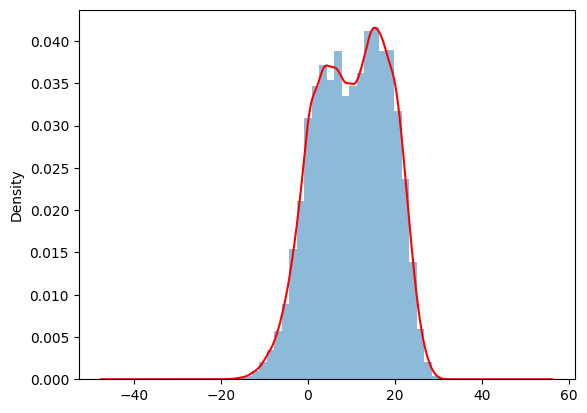

In [51]:
weather['TAVG'].plot(kind='hist', bins=30, density=True, alpha=0.5)
weather['TAVG'].plot(kind='kde', color="red")
plt.savefig('./outputs/tavg_hist.png', dpi=300)

# Export DataFrame
## Excel

In [ ]:
corr_matrix = weather.corr(numeric_only = True)

In [ ]:
corr_matrix.to_excel('./outputs/corr_matrix.xlsx', sheet_name='korelace')
corr_matrix.style.background_gradient(cmap='seismic', vmin=-1, vmax=1).to_excel('./outputs/corr_matrix.xlsx', sheet_name='korelace2')